<a href="https://colab.research.google.com/github/Zee5h4n/lessons-learned/blob/Plan-Disease-recogition-by-using-tranformar/plan_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Plan Disease recogition by using tranformar**

In [2]:
#Import librieres
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import zipfile
import random
from pathlib import Path
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models
import timm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
#Gdrive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [6]:
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/plant.zip'
extract_path = '/content/plant_disease_data'

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
print("Extracting ZIP file...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Extracting ZIP file...
✓ Files extracted to: /content/plant_disease_data


In [7]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')

plant_disease_data/
  Test/
    Test/
      Healthy/
        8ed56dd8b2c1c15a.jpg
        8f2071c7987e86ea.jpg
        8def4d91382175c3.jpg
        ... and 47 more files
      Rust/
        84c2b48da27b8cf7.jpg
        87e8cb11791fd078.jpg
        90fcd8e1fb2e003d.jpg
        ... and 47 more files
      Powdery/
        9f08c72693f34da4.jpg
        82ed3df137424aa6.jpg
        9ee39c2337175550.jpg
        ... and 47 more files
  Validation/
    Validation/
      Healthy/
        9be41b823d13e3c6.jpg
        9ce01ba1856fc6ad.jpg
        9c3684213b2f0fdd.jpg
        ... and 17 more files
      Rust/
        885e1bc6a3674eb1.jpg
        920e33d67f8b01b3.jpg
        8152cfbd5a28b5d2.jpg
        ... and 17 more files
      Powdery/
        9a962f656993095b.jpg
        9ab326c1951acb7a.jpg
        9a96746d61e5c43c.jpg
        ... and 17 more files
  Train/
    Train/
      Healthy/
        9d788a91891b8f79.jpg
        94e4d8968d9bb499.jpg
        98b039a386bbde07.jpg
        ... and 455 more

In [10]:
#Data Exploration
data_dir = os.path.join(extract_path, 'Train', 'Train')

# Get class names
class_names = sorted(os.listdir(data_dir))
num_classes = len(class_names)

print(f"\n{'='*70}")
print(f"DATASET INFORMATION")
print(f"{'='*70}")
print(f"Number of Classes: {num_classes}")
print(f"\nClass Names:")
for idx, name in enumerate(class_names, 1):
    print(f"{idx:2d}. {name}")


DATASET INFORMATION
Number of Classes: 3

Class Names:
 1. Healthy
 2. Powdery
 3. Rust


In [11]:
#count images par class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_name] = count

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)

print(f"\n{'='*70}")
print("Images per Class:")
print(df_counts.to_string(index=False))
print(f"\nTotal Images: {df_counts['Count'].sum()}")
print(f"Average per Class: {df_counts['Count'].mean():.0f}")


Images per Class:
  Class  Count
Healthy    458
   Rust    434
Powdery    430

Total Images: 1322
Average per Class: 441


In [12]:
#DATASET CLASS
class PlantDiseaseDataset(Dataset):
    """Custom Dataset for Plant Disease Images"""

    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Collect all image paths and labels
        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_dir, img_name)
                    self.images.append(img_path)
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return image, label

In [14]:
#get class member by using object
model = PlantDiseaseDataset

In [15]:
model

__main__.PlantDiseaseDataset

In [16]:
#DATA AUGMENTATION
IMG_SIZE = 224  # Standard for Vision Transformer

# TRAINING Transforms (WITH Augmentation)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=40, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MotionBlur(blur_limit=5),
    ], p=0.3),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean (normalization)
        std=[0.229, 0.224, 0.225]     # ImageNet std
    ),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1374347779.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


In [17]:
# VALIDATION/TEST Transforms
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print("Data augmentation pipelines created!")
print("  - Training: WITH augmentation + normalization")
print("  - Validation/Test: WITHOUT augmentation, ONLY normalization")


Data augmentation pipelines created!
  - Training: WITH augmentation + normalization
  - Validation/Test: WITHOUT augmentation, ONLY normalization


In [18]:
# SECTION 7: CREATE DATASETS AND DATALOADERS
full_dataset = PlantDiseaseDataset(data_dir, transform=None)

# Split into train, val, test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [19]:
#  Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

In [20]:
#  Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n{'='*70}")
print("DATASET SPLITS")
print(f"{'='*70}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Number of classes:  {num_classes}")


DATASET SPLITS
Training samples:   925
Validation samples: 198
Test samples:       199
Batch size:         32
Number of classes:  3


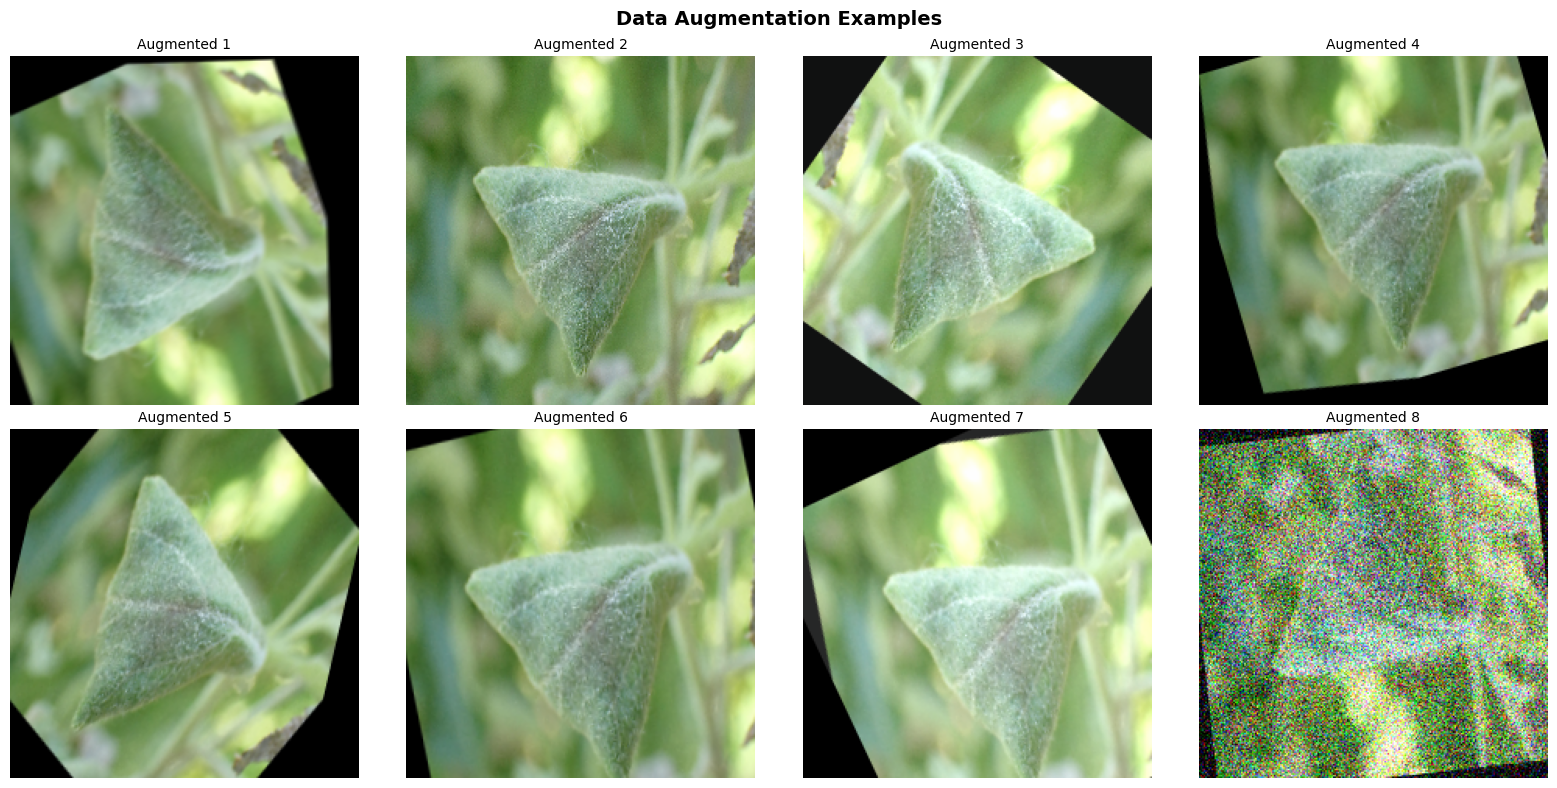

Augmentation visualization saved!


In [22]:
# VISUALIZE AUGMENTATION
def visualize_augmentation(dataset, num_samples=8):
    """Show augmentation effects"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # Get a sample image
    sample_idx = random.randint(0, len(dataset)-1)
    img_path = dataset.dataset.images[sample_idx]
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    for idx in range(num_samples):
        # Apply augmentation
        transformed = train_transform(image=original_img)
        aug_img = transformed['image']

        # Convert tensor to image for display
        aug_img = aug_img.permute(1, 2, 0).numpy()
        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        aug_img = std * aug_img + mean
        aug_img = np.clip(aug_img, 0, 1)

        axes[idx].imshow(aug_img)
        axes[idx].axis('off')
        axes[idx].set_title(f'Augmented {idx+1}', fontsize=10)

    plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/augmentation_pytorch.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Augmentation visualization saved!")

visualize_augmentation(train_dataset)

In [26]:
#Vision Transformer model
class PlantDiseaseViT(nn.Module):

    def __init__(self, num_classes, model_name='vit_base_patch16_224', pretrained=True):
        super(PlantDiseaseViT, self).__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [27]:
PlantDiseaseViT

__main__.PlantDiseaseViT

In [28]:
# Alternative: Using ConvNeXt (Transformer-inspired CNN)
class PlantDiseaseConvNeXt(nn.Module):
    """
    ConvNeXt model - Transformer-inspired CNN architecture
    Often achieves better accuracy than pure ViT on smaller datasets
    """
    def __init__(self, num_classes, model_name='convnext_tiny', pretrained=True):
        super(PlantDiseaseConvNeXt, self).__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PlantDiseaseViT(num_classes=num_classes, model_name='vit_base_patch16_224', pretrained=True)

In [31]:
model = model.to(device)

print(f"\n{'='*70}")
print("MODEL ARCHITECTURE")
print(f"{'='*70}")
print(f"Model: Vision Transformer (ViT)")
print(f"Pre-trained: Yes (ImageNet)")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



MODEL ARCHITECTURE
Model: Vision Transformer (ViT)
Pre-trained: Yes (ImageNet)
Number of classes: 3
Device: cpu

Total parameters: 85,800,963
Trainable parameters: 85,800,963
